## What are the most demanded skills for the top 3 most popular data roles?

### Methodology:

1. Clean-up skill column
2. Calculate skill count based on job_title_short
3. Calculate skill percentage
4. Plot final findings

In [2]:
# Importing modules
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

# Clean-up
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

df_SE = df[df['job_country'] == 'Sweden']

Using the latest cached version of the dataset since lukebarousse/data_jobs couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\kposp\.cache\huggingface\datasets\lukebarousse___data_jobs\default\0.0.0\1d815e9ce232eb27db11939c44eb048fe6d2e9ab (last modified on Mon Aug  5 20:05:58 2024).


In [3]:
df_skills = df_SE.explode('job_skills')
df_skills[['job_title', 'job_skills']]

,job_title,job_skills
213,Product Analyst,outlook
213,Product Analyst,excel
213,Product Analyst,word
213,Product Analyst,powerpoint
213,Product Analyst,power bi
...,...,...
785428,Data Engineer,snowflake
785428,Data Engineer,flow
785623,Data Engineer,None
785680,Software Engineer Level 3,c++


In [6]:
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = df_skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

df_skills_count

,job_skills,job_title_short,skill_count
672,python,Data Engineer,1078
851,sql,Data Engineer,976
58,azure,Data Engineer,725
673,python,Data Scientist,636
48,aws,Data Engineer,548
...,...,...,...
444,kubernetes,Business Analyst,1
869,ssis,Cloud Engineer,1
418,julia,Senior Data Scientist,1
414,jquery,Software Engineer,1


In [7]:
job_titles = df_skills_count['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3])

job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

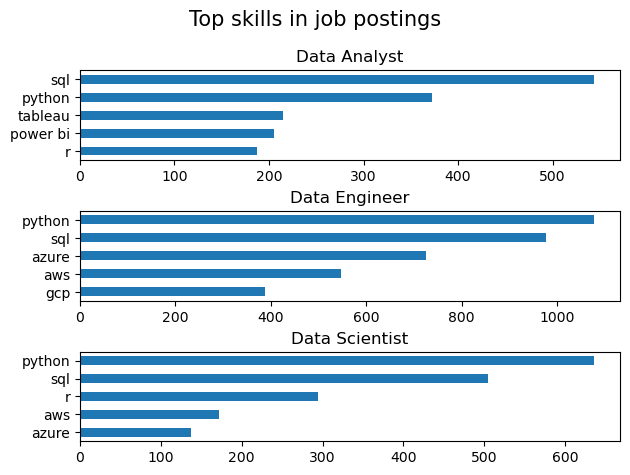

In [10]:
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)

fig.suptitle('Top skills in job postings', fontsize=15)
fig.tight_layout(h_pad=0.5)
plt.show()

In [13]:
df_job_title_count = df_SE['job_title_short'].value_counts().reset_index(name='jobs_total')

In [17]:
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, how='left', on='job_title_short')
df_skills_perc['skill_perc'] = 100 *df_skills_perc['skill_count'] / df_skills_perc['jobs_total']

df_skills_perc

,job_skills,job_title_short,skill_count,jobs_total,skill_perc
0,python,Data Engineer,1078,1757,61.354582
1,sql,Data Engineer,976,1757,55.549232
2,azure,Data Engineer,725,1757,41.263517
3,python,Data Scientist,636,1029,61.807580
4,aws,Data Engineer,548,1757,31.189528
...,...,...,...,...,...
1017,kubernetes,Business Analyst,1,444,0.225225
1018,ssis,Cloud Engineer,1,277,0.361011
1019,julia,Senior Data Scientist,1,252,0.396825
1020,jquery,Software Engineer,1,864,0.115741


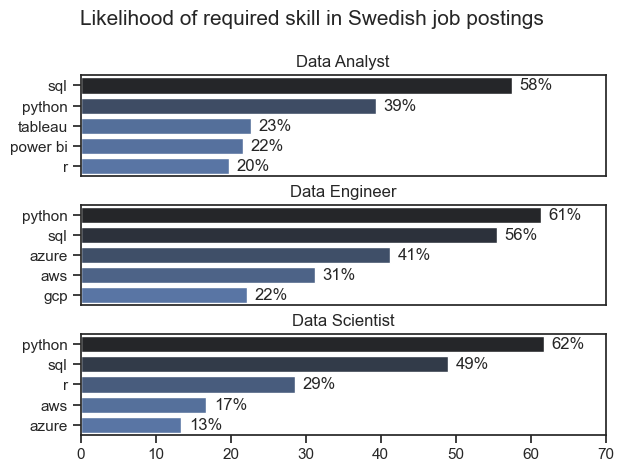

In [34]:
fig, ax = plt.subplots(len(job_titles), 1)
sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_perc', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0,70)

    for n, v in enumerate(df_plot['skill_perc']):
        ax[i].text(v + 1, n, f"{v:.0f}%", va='center')

    if i != len(job_titles) - 1:
        ax[i].set_xticks([])

fig.suptitle('Likelihood of required skill in Swedish job postings', fontsize=15)
fig.tight_layout(h_pad=0.5)
plt.show()